In [2]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from geopy import distance

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_sample_weight

#Removed tensorflow and keras

# Assignment 4 - Simple Neural Networks

For this assigment you'll do a realistic task - predicting fraud from transaction data. 
### Some Things to Note

<ul>
<li> The dataset is imbalanced. See: https://www.tensorflow.org/tutorials/structured_data/imbalanced_data for some ideas
<li> The locations, time, dob all likely aren't super useful on their own, but can be made into something more useful without much code or trouble. Think about how it may be useful to represent them. The data doesn't have missing rows, so this is the main data prep portion. 
<li> With respect to the above, and the other data here, we have a lot of rows of data. That means that we can generally handle data that is reasonably wide...
</ul>

### Deliverables

Your final goal is to produce a function that can be called to classify a transaction:
<ul>
<li> Please submit two .ipynb files - one where you did your work, and another that can use your model to make predictions. 
<li> In that prediction file, please ensure:
    <ul>
    <li> You have a function where I can load a file, and the end result is a classificaiton matrix of your prediction accuracy. 
    <li> You load a trained model. There's no training here. 
    <li> Any data prep stuff that is needed for your data should be built in here. I'm going to run a test file that is the exact same setup as the training data.
    <li> I should be able to open the prediction file, load the test data, and click RUN ALL and things should work. 
    <li> In addition to that, please include a short (~1-2 paragraph) description of what you did. Include anything that was innovative/different as well as a note on:
        <ul>
        <li> Any imbalanced data steps. 
        <li> Treatment of the location and time variables. What did you do to them?
        <li> Model structure (layers/size)
        <li> Any optimization steps included - regularization, dropouts, feature selection, etc...
        </ul>
    </ul>
</ul>

### Grades

The grade breakdown is as follows:

<ul>
<li> Code preduces predictions - 40
<li> Accuracy - 30
<li> Explaination - 20
<li> Balance/variable transformations - 10
</ul>



In [7]:
df = pd.read_csv("fraudTrain.csv.zip")
df.drop(columns={"Unnamed: 0"}, inplace=True)
df.head()


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
trans_date_trans_time,1296675,1274791,2019-04-22 16:02:01,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc_num,1296675.0,NaN,NaN,NaN,417192042079726656.0,1308806447000789248.0,60416207185.0,180042946491150.0,3521417320836166.0,4642255475285942.0,4992346398065154048.0
merchant,1296675,693,fraud_Kilback LLC,4403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1296675,14,gas_transport,131659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amt,1296675.0,NaN,NaN,NaN,70.351035,160.316039,1.0,9.65,47.52,83.14,28948.9
first,1296675,352,Christopher,26669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,1296675,481,Smith,28794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1296675,2,F,709863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street,1296675,983,864 Reynolds Plains,3123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1296675,894,Birmingham,5617,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Deal with Lat/Lon

We can utilize lat/lon of the home and merchant in a useful way?

Note: I left the section headers in from when I did it. You can remove them if you want. 

In [9]:
def compute_distance(row):
    home  = (row['lat'],       row['long'])
    merch = (row['merch_lat'], row['merch_long'])
    return distance.distance(home, merch).km

print("Computing distances (this may take a minute)...")
df['dist_km'] = df.apply(compute_distance, axis=1)
print("Done.")
df[['dist_km','is_fraud']].groupby('is_fraud').mean()


Computing distances (this may take a minute)...
Done.


,dist_km
is_fraud,
0,76.111582
1,76.266532


### Deal with Time

Can we make date/time and the date of birth into something useful?

- Cyclically encode hour-of-day and day-of-week (sin/cos) so 11pm and midnight are numerically close
- Derive customer age from `dob`

In [10]:
df['trans_dt'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob_dt']   = pd.to_datetime(df['dob'])

hour = df['trans_dt'].dt.hour
dow  = df['trans_dt'].dt.dayofweek

df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
df['dow_sin']  = np.sin(2 * np.pi * dow  / 7)
df['dow_cos']  = np.cos(2 * np.pi * dow  / 7)
df['age']      = (df['trans_dt'] - df['dob_dt']).dt.days / 365.25

df[['hour_sin','hour_cos','dow_sin','dow_cos','age']].describe()

,hour_sin,hour_cos,dow_sin,dow_cos,age
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,-1.366887e-01,-1.406000e-02,-1.086901e-01,1.285135e-01,4.599640e+01
std,6.932213e-01,7.075051e-01,6.846294e-01,7.091926e-01,1.739402e+01
min,-1.000000e+00,-1.000000e+00,-9.749279e-01,-9.009689e-01,1.392197e+01
25%,-8.660254e-01,-7.071068e-01,-7.818315e-01,-2.225209e-01,3.259959e+01
50%,-2.588190e-01,-1.836970e-16,0.000000e+00,6.234898e-01,4.396988e+01
75%,5.000000e-01,7.071068e-01,4.338837e-01,6.234898e-01,5.707050e+01
max,1.000000e+00,1.000000e+00,9.749279e-01,1.000000e+00,9.563860e+01


### Check Target Balance

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Fraud rate: 0.58%


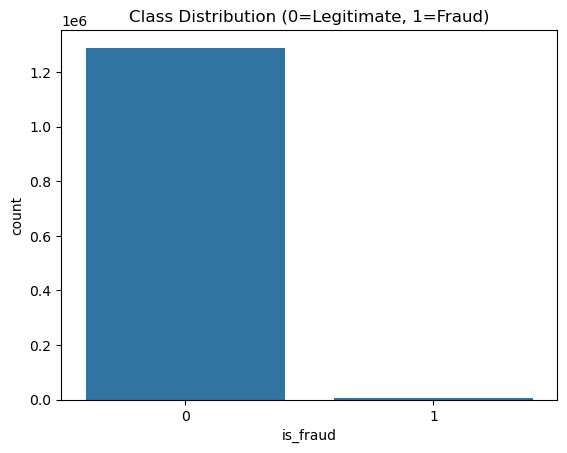

In [11]:
counts = df['is_fraud'].value_counts()
print(counts)
print(f"\nFraud rate: {counts[1]/len(df)*100:.2f}%")

sns.countplot(x='is_fraud', data=df)
plt.title('Class Distribution (0=Legitimate, 1=Fraud)')
plt.show()

### Prepare Data


In [12]:
drop_cols = [
    'trans_date_trans_time', 'trans_dt', 'dob', 'dob_dt',
    'cc_num', 'merchant', 'first', 'last', 'street',
    'city', 'state', 'zip', 'job', 'trans_num',
    'lat', 'long', 'merch_lat', 'merch_long',
    'unix_time'
]

df_model = df.drop(columns=drop_cols, errors='ignore')
df_model = pd.get_dummies(df_model, columns=['category', 'gender'], drop_first=False)

print(df_model.shape)
df_model.head()

(1296675, 25)


,amt,city_pop,is_fraud,dist_km,hour_sin,hour_cos,dow_sin,dow_cos,age,category_entertainment,...,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_F,gender_M
0,4.97,3495,0,78.773821,0.0,1.0,0.781831,0.62349,30.814511,False,...,False,False,True,False,False,False,False,False,True,False
1,107.23,149,0,30.216618,0.0,1.0,0.781831,0.62349,40.531143,False,...,False,False,False,False,False,False,False,False,True,False
2,220.11,4154,0,108.102912,0.0,1.0,0.781831,0.62349,56.950034,True,...,False,False,False,False,False,False,False,False,False,True
3,45.00,1939,0,95.685115,0.0,1.0,0.781831,0.62349,51.969884,False,...,False,False,False,False,False,False,False,False,False,True
4,41.96,99,0,77.702395,0.0,1.0,0.781831,0.62349,32.763860,False,...,False,False,False,True,False,False,False,False,False,True


### Split Data

In [13]:
X = df_model.drop(columns=['is_fraud']).values.astype(np.float32)
y = df_model['is_fraud'].values.astype(np.float32)

# Save feature names so the prediction notebook can align columns
feature_names = df_model.drop(columns=['is_fraud']).columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')
print(f"Features saved: {len(feature_names)} columns")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  Val: {X_val.shape}")

Features saved: 24 columns
Train: (1037340, 24)  Val: (259335, 24)


### Scale Features

In [14]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved.")

Scaler saved.


## Handle Class Imbalance
Use `compute_sample_weight('balanced')` so the rare fraud class gets proportionally higher weight during training.

In [15]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
print(f"Weight for legit: {sample_weights[y_train==0][0]:.4f}")
print(f"Weight for fraud: {sample_weights[y_train==1][0]:.4f}")

Weight for legit: 0.5029
Weight for fraud: 86.3730


## Build & Train the Model

**Architecture:** 3 hidden layers (128 → 64 → 32), ReLU activations.

**Regularization/optimization:**
- `alpha=1e-4` — L2 weight regularization
- `early_stopping=True` — stops when validation loss stops improving (patience=5)
- `learning_rate='adaptive'` — reduces LR when loss plateaus
- `batch_size=512` — mini-batch for speed on large dataset

In [16]:
model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=512,
    learning_rate='adaptive',
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5,
    random_state=42,
    verbose=True
)

print("Training model...")
model.fit(X_train_sc, y_train, sample_weight=sample_weights)
print(f"\nTraining complete. Stopped after {model.n_iter_} iterations.")

Training model...
Iteration 1, loss = 0.20925737
Validation score: 0.926381
Iteration 2, loss = 0.12293868
Validation score: 0.949799
Iteration 3, loss = 0.10442418
Validation score: 0.949989
Iteration 4, loss = 0.09368985
Validation score: 0.959220
Iteration 5, loss = 0.08510142
Validation score: 0.960431
Iteration 6, loss = 0.08315579
Validation score: 0.957959
Iteration 7, loss = 0.07816688
Validation score: 0.965183
Iteration 8, loss = 0.07705194
Validation score: 0.962809
Iteration 9, loss = 0.07376253
Validation score: 0.959403
Iteration 10, loss = 0.06866325
Validation score: 0.960927
Iteration 11, loss = 0.07022255
Validation score: 0.963895
Iteration 12, loss = 0.06819631
Validation score: 0.966985
Iteration 13, loss = 0.06563660
Validation score: 0.968944
Iteration 14, loss = 0.06451569
Validation score: 0.965105
Iteration 15, loss = 0.06341943
Validation score: 0.962415
Iteration 16, loss = 0.06127793
Validation score: 0.966118
Iteration 17, loss = 0.06141664
Validation scor

## Evaluate on Validation Set

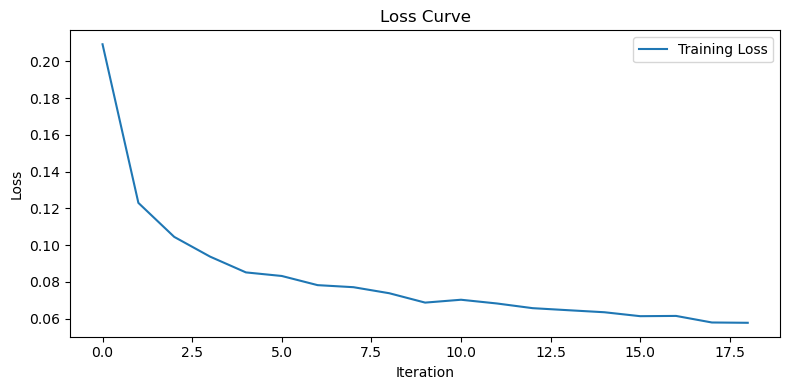

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_, label='Training Loss')
plt.title('Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

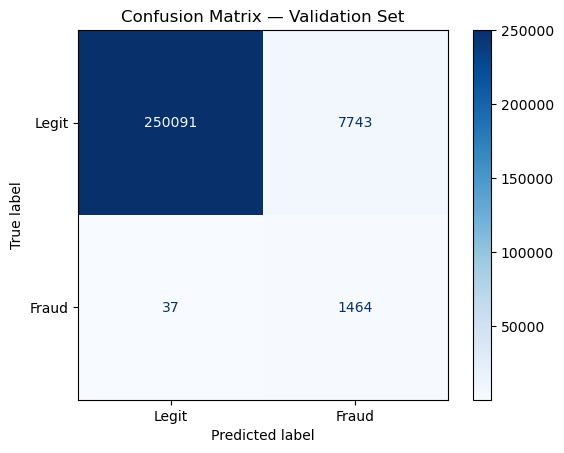

              precision    recall  f1-score   support

       Legit       1.00      0.97      0.98    257834
       Fraud       0.16      0.98      0.27      1501

    accuracy                           0.97    259335
   macro avg       0.58      0.97      0.63    259335
weighted avg       0.99      0.97      0.98    259335



In [18]:
y_pred = model.predict(X_val_sc)

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Validation Set')
plt.show()

print(classification_report(y_val, y_pred, target_names=['Legit', 'Fraud']))

## Save the Trained Model

In [19]:
joblib.dump(model, 'fraud_model.pkl')
print("Model saved to  fraud_model.pkl")
print("Scaler saved to scaler.pkl")
print("Features saved to feature_names.pkl")

Model saved to  fraud_model.pkl
Scaler saved to scaler.pkl
Features saved to feature_names.pkl


## Summary

**Data preparation:**
- **Location**: Computed geodesic distance (km) between cardholder home and merchant using `geopy`. Transactions far from home are a strong fraud indicator. Raw lat/lon dropped afterward.
- **Time**: Extracted hour-of-day and day-of-week from `trans_date_trans_time`, then cyclically encoded both with sin/cos pairs so that e.g. 11pm and midnight are numerically close. Parsed `dob` to derive customer age.
- **Categoricals**: One-hot encoded `category` (transaction type) and `gender`.
- **Dropped**: Identifier columns (cc_num, name, address, trans_num), raw datetime strings, raw lat/lon.

**Imbalanced data**: The dataset is ~0.5% fraud. We used `compute_sample_weight('balanced')` to give the minority fraud class proportionally higher weight during training, preventing the model from simply predicting 'legitimate' for everything.

**Model structure**: scikit-learn `MLPClassifier` with three hidden layers (128 → 64 → 32 neurons), ReLU activations, and Adam optimizer. L2 regularization (`alpha=1e-4`) and adaptive learning rate reduce overfitting. `early_stopping=True` (patience=5) halts training when validation performance stops improving.


**Note**: Removed tensorflow and keras because I don't have that module and it's taking me too long to install/add it. 